In [1]:
import pandas as pd
import numpy as np

import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px

## Initial inputs

define data paths

In [18]:
mpath = './'
dpath = mpath+'hydrosmade_v1/'

read attribute table

In [3]:
df_site_att = pd.read_csv(mpath+'site_attributes.csv')

df_site_att.columns

Index(['site id', 'status', 'type', 'longitude', 'latitude',
       'generation capacity (MW)', 'maximum turbine flow (m3/s)',
       'dam height (m)', 'head (m)', 'upstream discharge area (km2)',
       'reservoir surface area (m2)', 'reservoir storage capacity (m3)',
       'capital cost (2020USD/KW)', 'O&M cost (2020USD/KW)', 'start year',
       'xanthos grid id', 'xanthos basin name'],
      dtype='object')

define which basin to test

In [4]:
## uncomment to check the list of basins available in HydroSMADE
# print(set(df_site_att['xanthos basin name']))

In [5]:
basin2chk = 'Amazon' #'Zambezi'

## sites within the basin of interest
sites2chk = list(df_site_att[df_site_att['xanthos basin name'] == basin2chk]['site id'])

## types of hydropower sites available within the basin
types = list(set(df_site_att[df_site_att['xanthos basin name'] == basin2chk]['type']))

len(sites2chk)

5395

## Create date and time weights

In [6]:
syr = 1950
date = pd.date_range(''+str(syr)+'-1', periods=(2100-syr+1)*12, freq='M')
years = np.arange(syr, 2101,1)

time_wt = [31,28.25,31,30,31,30,31,31,30,31,30,31] * (2100-syr+1)

len(time_wt)

1812

### Scenarios

In [7]:
ssp = ['ssp126', 'ssp370', 'ssp585']

model = ['canesm5', 'cnrm-cm6-1', 'cnrm-esm2-1', 'ec-earth3', 'gfdl-esm4',
         'ipsl-cm6a-lr', 'miroc6', 'mpi-esm1-2-hr', 'mri-esm2-0', 'ukesm1-0-ll']

member = ['r1i1p1f1', 'r1i1p1f2', 'r1i1p1f2', 'r1i1p1f1' , 'r1i1p1f1', 
          'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2']

## Estimate basin-scale monthly mean hydro availability

In [8]:
list_basin_monthly_mean_mw_all = []


for k in range(len(types)):
    for j in range(len(ssp)):
        for i in range(len(model)):

            df_sites_mw = pd.read_csv(
                            dpath+'site_level_monthly_hydro_mw_1950_2100_'+types[k]+'_'+ssp[j]+'_'+model[i]+'_'+member[i]+'.csv', 
                                                                                            index_col=0)
            
            df_sites_mw2chk = df_sites_mw[df_sites_mw.index.isin(sites2chk)].copy()
            
            
            df_basin_monthly_mw = df_sites_mw2chk.sum(axis=0)
            df_basin_monthly_mw.index = date
            
            df_basin_monthly_mean_mw = df_basin_monthly_mw.groupby(df_basin_monthly_mw.index.month).mean()
            
            df_basin_monthly_mean_mw['type'] = types[k]
            df_basin_monthly_mean_mw['ssp'] = ssp[j]
            df_basin_monthly_mean_mw['model'] = model[i]
            
            list_basin_monthly_mean_mw_all.append(df_basin_monthly_mean_mw)
            
            print(types[k], ssp[j], model[i])

large_storage ssp126 canesm5
large_storage ssp126 cnrm-cm6-1
large_storage ssp126 cnrm-esm2-1
large_storage ssp126 ec-earth3
large_storage ssp126 gfdl-esm4
large_storage ssp126 ipsl-cm6a-lr
large_storage ssp126 miroc6
large_storage ssp126 mpi-esm1-2-hr
large_storage ssp126 mri-esm2-0
large_storage ssp126 ukesm1-0-ll
large_storage ssp370 canesm5
large_storage ssp370 cnrm-cm6-1
large_storage ssp370 cnrm-esm2-1
large_storage ssp370 ec-earth3
large_storage ssp370 gfdl-esm4
large_storage ssp370 ipsl-cm6a-lr
large_storage ssp370 miroc6
large_storage ssp370 mpi-esm1-2-hr
large_storage ssp370 mri-esm2-0
large_storage ssp370 ukesm1-0-ll
large_storage ssp585 canesm5
large_storage ssp585 cnrm-cm6-1
large_storage ssp585 cnrm-esm2-1
large_storage ssp585 ec-earth3
large_storage ssp585 gfdl-esm4
large_storage ssp585 ipsl-cm6a-lr
large_storage ssp585 miroc6
large_storage ssp585 mpi-esm1-2-hr
large_storage ssp585 mri-esm2-0
large_storage ssp585 ukesm1-0-ll
local_storage ssp126 canesm5
local_storage ssp

In [9]:
len(list_basin_monthly_mean_mw_all)

120

### Concat data for all scenarios and separate data for diversion and storage

In [10]:
df_basin_monthly_mean_mw_all = pd.concat([list_basin_monthly_mean_mw_all[x] for x in 
                                          range(len(list_basin_monthly_mean_mw_all))], axis=1).transpose()

df_basin_monthly_mean_mw_div = df_basin_monthly_mean_mw_all[df_basin_monthly_mean_mw_all.type.isin(['large_diversion', 
                                                                                                    'local_diversion'])].copy()

df_basin_monthly_mean_mw_stor = df_basin_monthly_mean_mw_all[df_basin_monthly_mean_mw_all.type.isin(['large_storage', 
                                                                                                     'local_storage'])].copy()

len(df_basin_monthly_mean_mw_div), len(df_basin_monthly_mean_mw_stor)

(60, 60)

## Calculate ensemble mean and std

for diversion-type sites if available

In [12]:
if len(df_basin_monthly_mean_mw_div)>0:
    df_basin_monthly_mean_mw_div_tot = df_basin_monthly_mean_mw_div.drop(columns=['type']).groupby(['ssp', 'model']).sum().reset_index()
    
    df_basin_monthly_mean_mw_div_ens_mean = df_basin_monthly_mean_mw_div_tot.drop(columns=['model']).groupby(['ssp']).mean().transpose()
    df_basin_monthly_mean_mw_div_ens_std = df_basin_monthly_mean_mw_div_tot.drop(columns=['model']).groupby(['ssp']).std().transpose()
    
    df_basin_monthly_mean_mw_div_ens_upper = df_basin_monthly_mean_mw_div_ens_mean + df_basin_monthly_mean_mw_div_ens_std
    df_basin_monthly_mean_mw_div_ens_lower = df_basin_monthly_mean_mw_div_ens_mean - df_basin_monthly_mean_mw_div_ens_std
    
len(df_basin_monthly_mean_mw_div)

60

for storage-type sites if available

In [13]:
if len(df_basin_monthly_mean_mw_stor)>0:
    df_basin_monthly_mean_mw_stor_tot = df_basin_monthly_mean_mw_stor.drop(columns=['type']).groupby(['ssp', 'model']).sum().reset_index()
    
    df_basin_monthly_mean_mw_stor_ens_mean = df_basin_monthly_mean_mw_stor_tot.drop(columns=['model']).groupby(['ssp']).mean().transpose()
    df_basin_monthly_mean_mw_stor_ens_std = df_basin_monthly_mean_mw_stor_tot.drop(columns=['model']).groupby(['ssp']).std().transpose()
    
    df_basin_monthly_mean_mw_stor_ens_upper = df_basin_monthly_mean_mw_stor_ens_mean + df_basin_monthly_mean_mw_stor_ens_std
    df_basin_monthly_mean_mw_stor_ens_lower = df_basin_monthly_mean_mw_stor_ens_mean - df_basin_monthly_mean_mw_stor_ens_std
    
len(df_basin_monthly_mean_mw_stor)

60

# Plot

for diversion-type sites if available

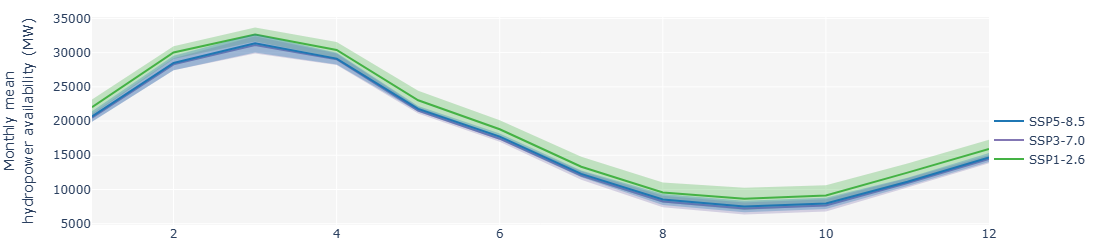

In [17]:
if len(df_basin_monthly_mean_mw_div)>0:
    fig = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.01)
    
    ###SSP126
    fig.add_trace(go.Scatter(name='SSP1-2.6', x=df_basin_monthly_mean_mw_div_ens_mean.index, 
                             y=df_basin_monthly_mean_mw_div_ens_mean['ssp126'],
                            mode='lines', line=dict(color='rgb(68, 178, 68)'),), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Upper Bound', x=df_basin_monthly_mean_mw_div_ens_upper.index, 
                             y=df_basin_monthly_mean_mw_div_ens_upper['ssp126'],
                             mode='lines',marker=dict(color="#444"),line=dict(width=0),showlegend=False), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Lower Bound', x=df_basin_monthly_mean_mw_div_ens_lower.index, 
                             y=df_basin_monthly_mean_mw_div_ens_lower['ssp126'], marker=dict(color="#444"), 
                            line=dict(width=0), mode='lines', fillcolor='rgba(68, 178, 68, 0.3)',fill='tonexty',showlegend=False), row=1, col=1)
    
    # ###SSP370    
    fig.add_trace(go.Scatter(name='SSP3-7.0', x=df_basin_monthly_mean_mw_div_ens_mean.index, 
                             y=df_basin_monthly_mean_mw_div_ens_mean['ssp370'],
                             mode='lines', line=dict(color='rgb(131, 119, 180)'),), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Upper Bound', x=df_basin_monthly_mean_mw_div_ens_upper.index, 
                             y=df_basin_monthly_mean_mw_div_ens_upper['ssp370'],
            mode='lines',marker=dict(color="#444"),line=dict(width=0),showlegend=False), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Lower Bound', x=df_basin_monthly_mean_mw_div_ens_lower.index, 
                             y=df_basin_monthly_mean_mw_div_ens_lower['ssp370'],marker=dict(color="#444"), 
                            line=dict(width=0), mode='lines', fillcolor='rgba(131, 119, 180, 0.3)',fill='tonexty',showlegend=False), row=1, col=1)
    
    # ###SSP585   
    fig.add_trace(go.Scatter(name='SSP5-8.5', x=df_basin_monthly_mean_mw_div_ens_mean.index, 
                             y=df_basin_monthly_mean_mw_div_ens_mean['ssp585'],
                            mode='lines', line=dict(color='rgb(31, 119, 180)'),), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Upper Bound', x=df_basin_monthly_mean_mw_div_ens_upper.index, 
                             y=df_basin_monthly_mean_mw_div_ens_upper['ssp585'],
                            mode='lines',marker=dict(color="#444"),line=dict(width=0),showlegend=False), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Lower Bound', x=df_basin_monthly_mean_mw_div_ens_lower.index, 
                             y=df_basin_monthly_mean_mw_div_ens_lower['ssp585'],marker=dict(color="#444"), 
                        line=dict(width=0), mode='lines', fillcolor='rgba(31, 119, 180, 0.3)',fill='tonexty', showlegend=False), row=1, col=1)
    
    
    fig.update_yaxes( tickformat='.0f') #type='log', 
    
    fig.update_layout(font = dict(size=12),width=600, height=250,
                      yaxis1 = dict(title="Monthly mean<br>hydropower availability (MW)"),
                      plot_bgcolor='#f5f5f5',#legend_traceorder="reversed",#showlegend=False)
                      legend=dict(yanchor="top",y=0.57,xanchor="left", x=1.00), 
                      margin=dict(l=10,r=10,b=10,t=15))
    
    fig.show()

for storage-type sites if available

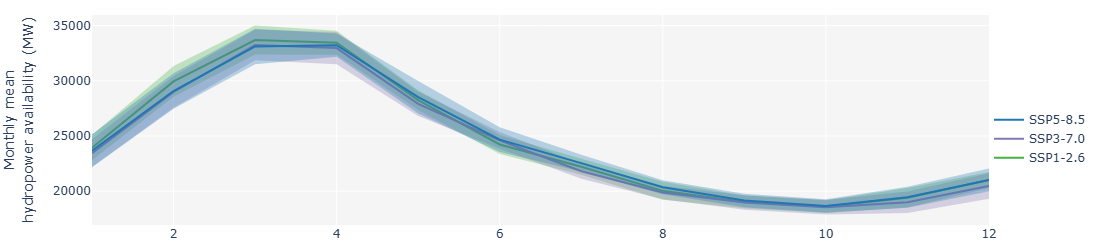

In [16]:
if len(df_basin_monthly_mean_mw_stor)>0:
    fig = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.01)
    
    ###SSP126
    fig.add_trace(go.Scatter(name='SSP1-2.6', x=df_basin_monthly_mean_mw_stor_ens_mean.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_mean['ssp126'],
                            mode='lines', line=dict(color='rgb(68, 178, 68)'),), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Upper Bound', x=df_basin_monthly_mean_mw_stor_ens_upper.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_upper['ssp126'],
                             mode='lines',marker=dict(color="#444"),line=dict(width=0),showlegend=False), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Lower Bound', x=df_basin_monthly_mean_mw_stor_ens_lower.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_lower['ssp126'], marker=dict(color="#444"), 
                            line=dict(width=0), mode='lines', fillcolor='rgba(68, 178, 68, 0.3)',fill='tonexty',showlegend=False), row=1, col=1)
    
    # ###SSP370    
    fig.add_trace(go.Scatter(name='SSP3-7.0', x=df_basin_monthly_mean_mw_stor_ens_mean.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_mean['ssp370'],
                             mode='lines', line=dict(color='rgb(131, 119, 180)'),), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Upper Bound', x=df_basin_monthly_mean_mw_stor_ens_upper.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_upper['ssp370'],
            mode='lines',marker=dict(color="#444"),line=dict(width=0),showlegend=False), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Lower Bound', x=df_basin_monthly_mean_mw_stor_ens_lower.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_lower['ssp370'],marker=dict(color="#444"), 
                            line=dict(width=0), mode='lines', fillcolor='rgba(131, 119, 180, 0.3)',fill='tonexty',showlegend=False), row=1, col=1)
    
    # ###SSP585   
    fig.add_trace(go.Scatter(name='SSP5-8.5', x=df_basin_monthly_mean_mw_stor_ens_mean.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_mean['ssp585'],
                            mode='lines', line=dict(color='rgb(31, 119, 180)'),), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Upper Bound', x=df_basin_monthly_mean_mw_stor_ens_upper.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_upper['ssp585'],
                            mode='lines',marker=dict(color="#444"),line=dict(width=0),showlegend=False), row=1, col=1)
        
    fig.add_trace(go.Scatter(name='Lower Bound', x=df_basin_monthly_mean_mw_stor_ens_lower.index, 
                             y=df_basin_monthly_mean_mw_stor_ens_lower['ssp585'],marker=dict(color="#444"), 
                        line=dict(width=0), mode='lines', fillcolor='rgba(31, 119, 180, 0.3)',fill='tonexty', showlegend=False), row=1, col=1)
    
    
    fig.update_yaxes( tickformat='.0f') #type='log', 
    
    fig.update_layout(font = dict(size=12),width=600, height=250,
                      yaxis1 = dict(title="Monthly mean<br>hydropower availability (MW)"),
                      plot_bgcolor='#f5f5f5',#legend_traceorder="reversed",#showlegend=False)
                      legend=dict(yanchor="top",y=0.57,xanchor="left", x=1.00), 
                      margin=dict(l=10,r=10,b=10,t=15))
    
    fig.show()